## SDV and MDS Processing Example

This notebook demonstrates how to process raw dendrometer sensor data to compute:

- Stem Diameter Variation (SDV)
- Normalized SDV (µm)
- Maximum Daily Shrinkage (MDS)

Input: raw sensor (ADC) values  
Output: SDV (mm, µm) and MDS (µm)

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [149]:
# Load data (make sure data.csv is in the same folder as the .pynb file)
df = pd.read_csv("data.csv")

# Convert timestamp column
df["Date"] = pd.to_datetime(df["Date"])

# Set as index
df = df.set_index("Date").sort_index()

df.head()

,Sensor
Date,
2025-08-03 00:03:51,202
2025-08-03 00:13:51,202
2025-08-03 00:23:51,202
2025-08-03 00:33:51,202
2025-08-03 00:43:51,202


In [151]:
# Resample to hourly means
df = df.resample("h").mean(numeric_only=True)

df.head()

,Sensor
Date,
2025-08-03 00:00:00,202.000000
2025-08-03 01:00:00,202.000000
2025-08-03 02:00:00,202.000000
2025-08-03 03:00:00,202.833333
2025-08-03 04:00:00,203.000000


In [153]:
# Convert sensor values to displacement (mm) using the calibration equation
df["SDV"] = 0.0125 * df["Sensor"] + 0.4

df.head()

,Sensor,SDV
Date,,
2025-08-03 00:00:00,202.000000,2.925000
2025-08-03 01:00:00,202.000000,2.925000
2025-08-03 02:00:00,202.000000,2.925000
2025-08-03 03:00:00,202.833333,2.935417
2025-08-03 04:00:00,203.000000,2.937500


In [155]:
# Normalize SDV relative to minimum
df["SDV_norm"] = df["SDV"] - df["SDV"].min()

#Optionally you can normalize relative to the first value 
#df["SDV_norm"] =df["SDV"] - df["SDV"].iloc[1]

# Convert to micrometers
df["SDV_um"] = df["SDV_norm"] * 1000

df.head()

,Sensor,SDV,SDV_norm,SDV_um
Date,,,,
2025-08-03 00:00:00,202.000000,2.925000,0.131250,131.250000
2025-08-03 01:00:00,202.000000,2.925000,0.131250,131.250000
2025-08-03 02:00:00,202.000000,2.925000,0.131250,131.250000
2025-08-03 03:00:00,202.833333,2.935417,0.141667,141.666667
2025-08-03 04:00:00,203.000000,2.937500,0.143750,143.750000


In [157]:
# Compute daily MDS (max - min)
mds = df["SDV_um"].resample("D").apply(
    lambda s: (s.max() - s.min()) if s.count() >= 2 else np.nan
)

# Convert to DataFrame and remove first day because it doesnt contain 24 h measurements
mds_df = mds.to_frame(name="MDS_um").iloc[1:]

mds_df.head()

,MDS_um
Date,
2025-08-04,143.75
2025-08-05,87.50
2025-08-06,100.00
2025-08-07,75.00
2025-08-08,87.50


In [126]:
SDV = calculate_SDV(df_resampled)
SDV = normalize_and_convert_to_um(SDV)
MDS = calculate_MDS(SDV)   

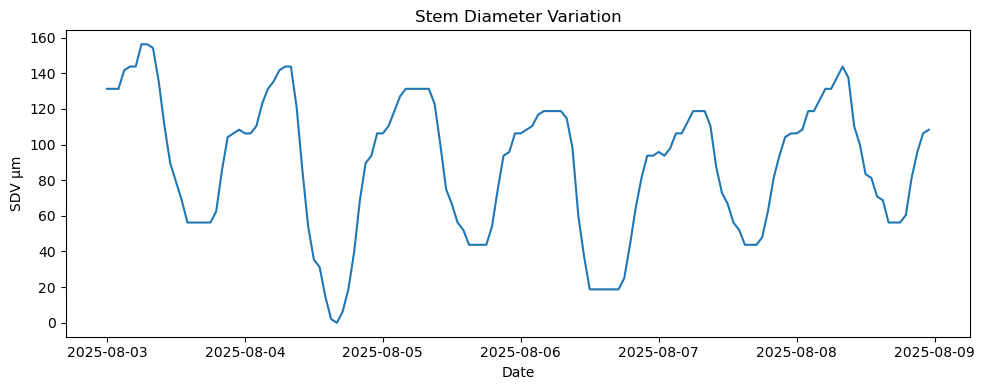

In [173]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["SDV_um"])
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.title("Stem Diameter Variation")
plt.ylabel("SDV µm")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

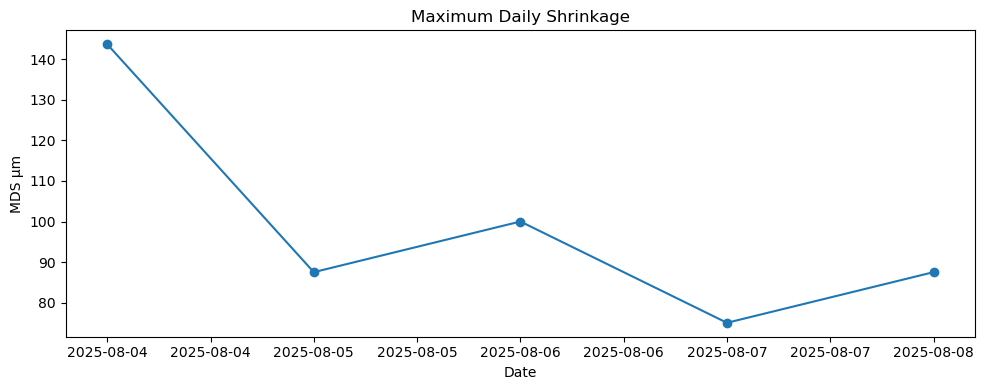

In [171]:
plt.figure(figsize=(10, 4))
plt.plot(mds_df.index, mds_df["MDS_um"], marker="o")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.title("Maximum Daily Shrinkage")
plt.ylabel("MDS µm")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("processed_sdv_data.csv")
mds_df.to_csv("mds_output.csv")